# **Mount Drive**

# **Load Data**

In [52]:
import pandas as pd
ffail = '<DATA_ROOT>/crop_failure_modified/crops_failure_0595_20240221.csv'
df_fail = pd.read_csv(ffail)
df_fail = df_fail.drop(columns=['Unnamed: 0'])

cond1 = df_fail['Planted Acres'] > 0
df_fail = df_fail[cond1]
df_fail.loc[:,'fail_share'] = df_fail['Failed Acres'] /  df_fail['Planted Acres']
df_fail = df_fail[df_fail.fail_share < 1]

cols = ['FIPS', 'Crop', 'Irrigation Practice', 'year', 'fail_share']

df_fail = df_fail[cols]
df_fail.groupby('Irrigation Practice').count()

,FIPS,Crop,year,fail_share
Irrigation Practice,,,,
ALL,217980,217980,217980,217980
I,70901,70901,70901,70901
N,162534,162534,162534,162534


In [53]:
import pandas as pd
import numpy as np
from scipy.signal import detrend

fpath_yield = '<DATA_ROOT>/Yield/crops_us_yield_agg_irig.csv'
dfy = pd.read_csv(fpath_yield)
df_grouped = dfy.groupby(['state_name','county_name','prodn_practice_desc','commodity_desc'])

def detrend_yield(yield_series):
  detrended_yield = np.zeros(len(yield_series))
  if len(yield_series) > 2:
    detrended_yield = detrend(yield_series)
  return pd.Series(detrended_yield, index=yield_series.index)

dfy['detrended_yield'] = df_grouped['value_yield'].transform(detrend_yield)
dfy['d_yield_standard'] = dfy['detrended_yield'] / (dfy['value_yield'] - dfy['detrended_yield'])

fpath_fips = '<DATA_ROOT>/Yield/yield_fips_code.csv'
dffipsy = pd.read_csv(fpath_fips).rename(columns={' county_code':'county_code'})
df_new = dffipsy.copy()
formatted_numbers = [str(n).zfill(3) for n in df_new['county_code'].values]
df_new['county_code'] = formatted_numbers
formatted_numbers = [str(n).zfill(2) for n in df_new['state_fips_code'].values]
df_new['state_fips_code'] = formatted_numbers
df_new['FIPS'] = df_new['state_fips_code'] + df_new['county_code']
dffipsy = df_new
dffipsy = dffipsy.drop(columns=['state_fips_code' , 'county_code'])
dffipsy

dfy = pd.merge(dfy,dffipsy,on=['state_name', 'county_name'])

cols = ['FIPS','commodity_desc','prodn_practice_desc','year','d_yield_standard']
df_yield = dfy[cols]
condy = df_yield.year > 2008
df_yield = df_yield[condy]
# df_yield
df_yield.groupby('prodn_practice_desc').count()

,FIPS,commodity_desc,year,d_yield_standard
prodn_practice_desc,,,,
ALL PRODUCTION PRACTICES,86700,86700,86700,86700
IRRIGATED,2946,2946,2946,2946
NON-IRRIGATED,3425,3425,3425,3425


In [54]:
from glob import glob
import pandas as pd
in_path = '<DATA_ROOT>/SVI_weightedCrop_modified_Final/*.csv'
files = glob(in_path)

list_df = []
for f in files:
  crop = f.split('/')[-1].split('.')[0][4:]
  # print(crop)
  dfi = pd.read_csv(f).copy()
  dfi['EPL_PCI'] = dfi['EPL_PCI'].fillna(dfi['EPL_HBURD'])
  dfi = dfi.drop(columns=['EPL_HBURD' ,	'EPL_UNINSUR'])
  dfi['Crop'] = crop
  list_df.append(dfi)

df_svi = pd.concat(list_df,ignore_index=True)
df_svi = df_svi.set_index(['STCNTY','YEAR','Crop']).dropna(how='all').reset_index()
df_svi = df_svi.rename(columns={'STCNTY':'FIPS','YEAR':'year'})
df_svi

,FIPS,year,Crop,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,RPL_THEME1,EPL_AGE65,EPL_AGE17,...,EPL_MINRTY,EPL_LIMENG,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,RPL_THEME4,RPL_THEMES
0,1009,2008,HAY,0.411000,0.269000,0.555000,0.623000,0.460000,0.394000,0.551000,...,0.154000,0.039000,0.002000,0.000000,0.947000,0.087000,0.174000,0.714000,0.458000,0.342000
1,1015,2008,HAY,0.440000,0.502000,0.430000,0.409000,0.431000,0.567000,0.293000,...,0.512000,0.149000,0.287000,0.435000,0.761000,0.050000,0.291000,0.000000,0.285000,0.322000
2,1043,2008,HAY,0.602000,0.376400,0.674400,0.718400,0.638000,0.541800,0.443200,...,0.069000,0.195600,0.069600,0.045800,0.916200,0.203400,0.471800,0.000000,0.270200,0.369200
3,1083,2008,HAY,0.562800,0.329280,0.555440,0.834680,0.610120,0.283880,0.512200,...,0.628960,0.331480,0.486560,0.012440,0.872000,0.522080,0.520000,0.039680,0.400400,0.496320
4,1089,2008,HAY,0.414111,0.390333,0.205222,0.235889,0.241000,0.192444,0.441667,...,0.557556,0.372444,0.469778,0.553111,0.706889,0.209778,0.168556,0.081111,0.310667,0.216556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279115,56037,2022,OATS,0.421756,0.641478,0.103969,0.282411,0.333217,0.673786,0.417695,...,0.147250,0.454942,0.147250,0.029158,0.956544,0.487839,0.138129,0.426352,0.420015,0.434108
279116,56039,2022,OATS,0.247541,0.171324,0.273629,0.168196,0.163031,0.507233,0.262789,...,0.276512,0.444131,0.276512,0.536832,0.651444,0.564276,0.410931,0.619973,0.709801,0.280541
279117,56041,2022,OATS,0.532133,0.641156,0.090844,0.394458,0.480949,0.363293,0.836505,...,0.268444,0.446553,0.268444,0.552860,0.968887,0.800458,0.332027,0.500506,0.777016,0.629125
279118,56043,2022,OATS,0.440896,0.350872,0.080058,0.266097,0.298983,0.784543,0.526574,...,0.135750,0.009997,0.135750,0.340103,0.828429,0.819263,0.402957,0.796382,0.855720,0.455858


In [55]:
import pandas as pd
import numpy as np
fpath_water = '<DATA_ROOT>/WaterUsage/WaterUse_crop_v3.csv'
dfw = pd.read_csv(fpath_water).rename(columns={'Year':'year'})
dfw = dfw[['FIPS','IR-WGWFr','IR-WSWFr','IR-WFrTo','IR-IrTot','year']]
dfw['IR-WGWFr'] = pd.to_numeric(dfw['IR-WGWFr'], errors='coerce')
dfw['IR-WSWFr'] = pd.to_numeric(dfw['IR-WSWFr'], errors='coerce')
dfw['IR-IrTot'] = pd.to_numeric(dfw['IR-IrTot'], errors='coerce')
dfw = dfw[dfw['IR-IrTot'] > 0]
dfw.loc[:,'wu_ratio'] = (dfw['IR-WGWFr'] > dfw['IR-WSWFr']).astype(int)
dfw.loc[:,'gwu_rate'] = dfw['IR-WGWFr'] / dfw['IR-IrTot']
dfw.loc[:,'swu_rate'] = dfw['IR-WSWFr'] / dfw['IR-IrTot']
formatted_numbers = [str(n).zfill(5) for n in dfw['FIPS'].values]
dfw['FIPS'] = formatted_numbers
dfw = dfw[['FIPS','year','gwu_rate','swu_rate']]
dfw['FIPS'] = dfw['FIPS'].astype(int)
dfw

,FIPS,year,gwu_rate,swu_rate
0,1001,2009,1.610738,0.255034
1,1003,2009,2.236618,0.428832
2,1005,2009,0.166667,0.498148
3,1007,2009,0.214286,0.428571
4,1009,2009,0.508475,0.779661
...,...,...,...,...
46609,56037,2023,0.416110,3.546957
46610,56039,2023,0.000000,6.989101
46611,56041,2023,0.573282,4.887083
46612,56043,2023,0.207130,6.698673


In [56]:
finsure = '<DATA_ROOT>/InsuranceData/InsuranceData.csv'
df_insure = pd.read_csv(finsure)
df_insure['FIPS'] = df_insure['State_Code'] * 1000 + df_insure['County_Code']
cols = ['FIPS', 'Commodity_Name', 'Year_Identifier','Cause_of_Loss_Code', 'Cause_of_Loss_Desc']
# cols = ['FIPS', 'Commodity_Name', 'Year_Identifier','Cause_of_Loss_Code', 'Cause_of_Loss_Desc','Subsidy','Liability']
df_insure = df_insure[cols]
df_insure = df_insure.rename(columns={'Commodity_Name':'Crop','Year_Identifier':'year'})
cond1 = df_insure['Cause_of_Loss_Code'] != 'XX'
df_insure = df_insure[cond1]
df_insure['Cause_of_Loss_Code'] = df_insure['Cause_of_Loss_Code'].astype(int)
df_insure = df_insure.groupby(['FIPS','Crop','year','Cause_of_Loss_Code']).first().reset_index()
df_insure

<ipython-input-56-c2fa01b3c2d3>:2: DtypeWarning: Columns (8,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_insure = pd.read_csv(finsure)


,FIPS,Crop,year,Cause_of_Loss_Code,Cause_of_Loss_Desc
0,1001,CORN,2008,11,Drought
1,1001,CORN,2009,1,Decline in Price
2,1001,CORN,2009,11,Drought
3,1001,CORN,2009,12,Heat
4,1001,CORN,2009,31,Excess Moisture/Precipitation/Rain
...,...,...,...,...,...
400252,56045,WHEAT,2016,1,Decline in Price
400253,56045,WHEAT,2016,11,Drought
400254,56045,WHEAT,2016,42,Freeze
400255,56045,WHEAT,2017,1,Decline in Price


In [57]:
fcold = '<DATA_ROOT>/ClimateIndex/ColdSpell.csv'
df_cold = pd.read_csv(fcold)
cols = ['FIPS','Year','Thr-2', 'Thr0', 'Thr2', 'Thr4', 'Thr6',
        'Thr8', 'Thr10', 'Thr12', 'Thr14', 'Thr16', 'Thr18']
df_cold = df_cold[cols]
df_cold = df_cold.dropna(subset=['FIPS', 'Year'])
df_cold['FIPS'] = df_cold['FIPS'].astype(int)
df_cold['Year'] = df_cold['Year'].astype(int)
df_cold = df_cold.rename(columns={'Year':'year'})

In [58]:
df_cold.columns

Index(['FIPS', 'year', 'Thr-2', 'Thr0', 'Thr2', 'Thr4', 'Thr6', 'Thr8',
       'Thr10', 'Thr12', 'Thr14', 'Thr16', 'Thr18'],
      dtype='object')

In [59]:
fdrought = '<DATA_ROOT>/ClimateIndex/list_droughtFeatures.csv'
df_drought = pd.read_csv(fdrought)
df_drought = df_drought.dropna(subset=['Fips', 'Year'])
df_drought['Fips'] = df_drought['Fips'].astype(int)
df_drought['Year'] = df_drought['Year'].astype(int)
df_drought = df_drought.rename(columns={'Fips':'FIPS'})
df_drought = df_drought.rename(columns={'Year':'year'})

In [60]:
df_drought.columns

Index(['FIPS', 'year', 'pdsi-1', 'pdsi-2', 'pdsi', 'spei180d-1', 'spei180d-2',
       'spei180d', 'spei1y-1', 'spei1y-2', 'spei1y', 'spei270d-1',
       'spei270d-2', 'spei270d', 'spei90d-1', 'spei90d-2', 'spei90d',
       'spi180d-1', 'spi180d-2', 'spi180d', 'spi1y-1', 'spi1y-2', 'spi1y',
       'spi270d-1', 'spi270d-2', 'spi270d', 'spi90d-1', 'spi90d-2', 'spi90d',
       'spei14d-1', 'spei14d-2', 'spei14d', 'spei30d-1', 'spei30d-2',
       'spei30d', 'spi14d-1', 'spi14d-2', 'spi14d', 'spi30d-1', 'spi30d-2',
       'spi30d'],
      dtype='object')

In [61]:
fprcp = '<DATA_ROOT>/ClimateIndex/prcp.csv'
df_prcp = pd.read_csv(fprcp)
df_prcp = df_prcp.dropna(subset=['FIPS', 'Year'])
df_prcp['FIPS'] = df_prcp['FIPS'].astype(int)
df_prcp['Year'] = df_prcp['Year'].astype(int)
df_prcp = df_prcp.drop(columns=['State','County'])
df_prcp = df_prcp.rename(columns={'Year':'year'})

In [62]:
df_prcp.columns

Index(['FIPS', 'year', 'dpi1', 'dpi5', 'dpi10', 'dpi20', 'dover1', 'dover5',
       'dover10', 'dover20'],
      dtype='object')

In [63]:
fvpd = '<DATA_ROOT>/ClimateIndex/new_vpdfeatures.csv'
df_vpd = pd.read_csv(fvpd)
df_vpd = df_vpd.dropna(subset=['FIPS', 'Year'])
df_vpd['FIPS'] = df_vpd['FIPS'].astype(int)
df_vpd['Year'] = df_vpd['Year'].astype(int)
df_vpd = df_vpd.drop(columns=['State','County'])
df_vpd = df_vpd.rename(columns={'Year':'year'})

In [64]:
df_vpd#.iloc[0:10000]

,FIPS,year,VPD-Mean,VPD-1,VPD-2
0,1001,2008,1.145214,125.0,1.0
1,1001,2009,0.947340,68.0,0.0
2,1001,2010,1.310861,147.0,7.0
3,1001,2011,1.690091,162.0,61.0
4,1001,2012,1.454901,157.0,19.0
...,...,...,...,...,...
46615,56045,2018,1.053937,93.0,14.0
46616,56045,2019,0.948979,81.0,8.0
46617,56045,2020,1.366875,117.0,44.0
46618,56045,2021,1.438504,123.0,51.0


In [65]:
fwarm = '<DATA_ROOT>/ClimateIndex/WarmSpell.csv'
df_warm = pd.read_csv(fwarm)
df_warm = df_warm.dropna(subset=['FIPS', 'Year'])
df_warm['FIPS'] = df_warm['FIPS'].astype(int)
df_warm['Year'] = df_warm['Year'].astype(int)
df_warm = df_warm.drop(columns=['State','County'])
df_warm = df_warm.rename(columns={'Year':'year'})

In [66]:
df_warm.columns

Index(['FIPS', 'year', 'Thr26', 'Thr27', 'Thr28', 'Thr29', 'Thr30', 'Thr31',
       'Thr32', 'Thr33', 'Thr34', 'Thr35', 'Thr36'],
      dtype='object')

In [67]:
# df_fail , df_yield , df_svi , dfw , df_insure

In [68]:
df_insure = df_insure.drop(columns=['Cause_of_Loss_Code'])
df_insure

,FIPS,Crop,year,Cause_of_Loss_Desc
0,1001,CORN,2008,Drought
1,1001,CORN,2009,Decline in Price
2,1001,CORN,2009,Drought
3,1001,CORN,2009,Heat
4,1001,CORN,2009,Excess Moisture/Precipitation/Rain
...,...,...,...,...
400252,56045,WHEAT,2016,Decline in Price
400253,56045,WHEAT,2016,Drought
400254,56045,WHEAT,2016,Freeze
400255,56045,WHEAT,2017,Decline in Price


In [69]:
df_svi = df_svi[['FIPS','Crop','year','RPL_THEMES']]
df_cold = df_cold[['FIPS', 'year','Thr6', 'Thr10', 'Thr12', 'Thr16',]]
        # 'Thr0', 'Thr2', 'Thr4', 'Thr6', 'Thr8', 'Thr10', 'Thr12', 'Thr14', 'Thr16', 'Thr18']]
df_drought = df_drought[['FIPS', 'year','spei90d-1','spei30d-2']] # 'spi1y-2'
df_prcp = df_prcp[['FIPS', 'year', 'dover1', 'dover5']]
df_vpd = df_vpd[['FIPS', 'year','VPD-Mean','VPD-1','VPD-2']]
df_warm = df_warm[['FIPS', 'year','Thr28','Thr30','Thr31','Thr33','Thr35']]


In [70]:
df_cold.columns

Index(['FIPS', 'year', 'Thr6', 'Thr10', 'Thr12', 'Thr16'], dtype='object')

# **Zahir**

In [ ]:
cond_irig = df_yield['prodn_practice_desc'] == 'ALL PRODUCTION PRACTICES'
df_yield = df_yield[cond_irig]
df_yield['prodn_practice_desc'] = 'ALL'
df_yield = df_yield.rename(columns={'commodity_desc':'Crop','prodn_practice_desc':'Irrigation Practice'})
df_yield['FIPS'] = df_yield['FIPS'].astype(int)

In [ ]:
df_merge_yield_ins = pd.merge(df_yield,df_insure,on=['FIPS', 'Crop', 'year'],how='outer',validate='m:m')
df_merge_yield_ins_svi = pd.merge(df_merge_yield_ins,df_svi,on=['FIPS', 'Crop', 'year'],how='outer',validate='m:1')
df_merge_yield_ins_svi_gwu = pd.merge(df_merge_yield_ins_svi,dfw,on=['FIPS', 'year'],how='outer',validate='m:1')
# df_merge_crop_ins_svi_gwu

df_merge_yield_ins_svi_gwu = df_merge_yield_ins_svi_gwu.dropna(subset='d_yield_standard')
condy = df_merge_yield_ins_svi_gwu.year < 2023
df_merge_yield_ins_svi_gwu = df_merge_yield_ins_svi_gwu[condy]

df_merge_clim = pd.merge(df_cold,df_drought,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_prcp,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_vpd,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_warm,on=['FIPS', 'year'])
# df_merge_clim

df_merge = pd.merge(df_merge_yield_ins_svi_gwu,df_merge_clim,on=['FIPS', 'year'],validate='m:1')
df_merge = df_merge.dropna()


In [ ]:
# Cause_of_Loss = [
#     'Insects',	'Plant Disease',	'Frost',	'Hot Wind',
#     'Wildlife',	'Freeze',	'Cold Winter',	'Wind/Excess Wind',
#     'Flood',	'Hail',	'Heat',	'Cold Wet Weather',	'Drought',
#     'Decline in Price',	'Excess Moisture/Precipitation/Rain'
# ]

Cause_of_Loss = [
    'Heat',	'Drought', 'Excess Moisture/Precipitation/Rain'
]

df_merge = df_merge[df_merge['Cause_of_Loss_Desc'].isin(Cause_of_Loss)]
df_merge

In [ ]:
cond_loss = df_merge['Cause_of_Loss_Desc'] == Cause_of_Loss[-1]
cond_ir = df_merge['Irrigation Practice'] == 'ALL'
df_merge_yield = df_merge[cond_ir & cond_loss]
# df_merge_yield = df_merge[cond_ir]

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

selected_crop = 'WHEAT' # 'WHEAT' , 'CORN' , 'SOYBEANS'
cond_crop = df_merge_yield.Crop == selected_crop
df = df_merge_yield[cond_crop].drop(columns=['FIPS','Crop','Irrigation Practice','year','Cause_of_Loss_Desc'])

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
# df_scaled

In [ ]:
import numpy as np
import random
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df_scaled.drop(columns=['d_yield_standard'])
y = df_scaled['d_yield_standard']

r2_test = 0
r2_train = 0
rst = 0
for rs in range(1,1000):
  # rs = 139
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=rs) #

  params = {'max_depth': 8,
              'learning_rate': 0.05,
              'subsample': 0.7,
              'n_estimators': 100,
            'random_state':rs
              }

  xgb_model = xgb.XGBRegressor(**params)
  xgb_model.fit(X_train, y_train)
  y_pred = xgb_model.predict(X_test)
  y_pred2 = xgb_model.predict(X_train)
  r2_ts = r2_score(y_test, y_pred)
  r2_tr = r2_score(y_train, y_pred2)

  if r2_ts > r2_test:
    rst = rs
    r2_test = r2_ts
    r2_train = r2_tr
    print(rs)
    print("R-squared_test:", r2_ts)
    print("R-squared_train:", r2_tr)

# **Yield Analysis Regression All Categories**

In [ ]:
cond_irig = df_yield['prodn_practice_desc'] == 'ALL PRODUCTION PRACTICES'
df_yield = df_yield[cond_irig]
df_yield['prodn_practice_desc'] = 'ALL'
df_yield = df_yield.rename(columns={'commodity_desc':'Crop','prodn_practice_desc':'Irrigation Practice'})
df_yield['FIPS'] = df_yield['FIPS'].astype(int)

In [ ]:
df_merge_yield_ins = pd.merge(df_yield,df_insure,on=['FIPS', 'Crop', 'year'],how='outer',validate='m:m')
df_merge_yield_ins_svi = pd.merge(df_merge_yield_ins,df_svi,on=['FIPS', 'Crop', 'year'],how='outer',validate='m:1')
df_merge_yield_ins_svi_gwu = pd.merge(df_merge_yield_ins_svi,dfw,on=['FIPS', 'year'],how='outer',validate='m:1')
# df_merge_crop_ins_svi_gwu

df_merge_yield_ins_svi_gwu = df_merge_yield_ins_svi_gwu.dropna(subset='d_yield_standard')
condy = df_merge_yield_ins_svi_gwu.year < 2023
df_merge_yield_ins_svi_gwu = df_merge_yield_ins_svi_gwu[condy]

df_merge_clim = pd.merge(df_cold,df_drought,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_prcp,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_vpd,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_warm,on=['FIPS', 'year'])
# df_merge_clim

df_merge = pd.merge(df_merge_yield_ins_svi_gwu,df_merge_clim,on=['FIPS', 'year'],validate='m:1')
df_merge = df_merge.dropna()


In [ ]:
df_merge

In [ ]:
Cause_of_Loss = [
    'Insects',	'Plant Disease',	'Frost',	'Hot Wind',
    'Wildlife',	'Freeze',	'Cold Winter',	'Wind/Excess Wind',
    'Flood',	'Hail',	'Heat',	'Cold Wet Weather',	'Drought',
    'Decline in Price',	'Excess Moisture/Precipitation/Rain'
]

df_merge = df_merge[df_merge['Cause_of_Loss_Desc'].isin(Cause_of_Loss)]
df_merge

In [ ]:
cond_loss = df_merge['Cause_of_Loss_Desc'] == Cause_of_Loss[-1]
cond_ir = df_merge['Irrigation Practice'] == 'ALL'
df_merge_yield = df_merge[cond_ir & cond_loss]
# df_merge_yield = df_merge[cond_ir]

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

selected_crop = 'WHEAT' # 'WHEAT' , 'CORN' , 'SOYBEANS'
cond_crop = df_merge_yield.Crop == selected_crop
df = df_merge_yield[cond_crop].drop(columns=['FIPS','Crop','Irrigation Practice','year','Cause_of_Loss_Desc',
                                              'spei30d-2','Thr28', 'Thr30', 'Thr31', 'Thr33','dover5',
                                              'VPD-Mean', 'VPD-1','Thr6', 'Thr10', 'Thr16',
                                              # 'VPD-Mean', 'VPD-1', 'Thr28', 'Thr30', 'Thr31', 'Thr33',
                                              # 'Thr6', 'Thr10', 'Thr12', 'spei30d-2','dover5',
                                                # 'VPD-Mean', 'VPD-1', 'Thr28', 'Thr30', 'Thr31', 'Thr33',
                                                # 'Thr6', 'Thr10', 'Thr12', 'spei90d-1','dover1',
                                              ])
# df = df_merge_yield.drop(columns=['FIPS','Crop','Irrigation Practice','year','Cause_of_Loss_Desc'])
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
# df_scaled

In [ ]:
df_merge_yield[cond_crop]
# df_scaled

In [ ]:
import numpy as np
import random
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df_scaled.drop(columns=['d_yield_standard'])
y = df_scaled['d_yield_standard']

r2_test = 0
r2_train = 0
rst = 0
for rs in range(1,1000):
  # rs = 139
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=rs) #

  params = {'max_depth': 8,
              'learning_rate': 0.05,
              'subsample': 0.7,
              'n_estimators': 100,
            'random_state':rs
              }

  xgb_model = xgb.XGBRegressor(**params)
  xgb_model.fit(X_train, y_train)
  y_pred = xgb_model.predict(X_test)
  y_pred2 = xgb_model.predict(X_train)
  r2_ts = r2_score(y_test, y_pred)
  r2_tr = r2_score(y_train, y_pred2)

  if r2_ts > r2_test:
    rst = rs
    r2_test = r2_ts
    r2_train = r2_tr
    print(rs)
    print("R-squared_test:", r2_ts)
    print("R-squared_train:", r2_tr)

1
R-squared_test: 0.21810023386389088
R-squared_train: 0.5840915677812699
18
R-squared_test: 0.2250087705249697
R-squared_train: 0.5790590548681268
33
R-squared_test: 0.23554279653400045
R-squared_train: 0.5775643876106347
35
R-squared_test: 0.24256072447395005
R-squared_train: 0.5822952215198753
51
R-squared_test: 0.24472512470737395
R-squared_train: 0.5797741930699983
94
R-squared_test: 0.24811573067021975
R-squared_train: 0.5765894899700368
117
R-squared_test: 0.2536454291808552
R-squared_train: 0.5842452059817671
378
R-squared_test: 0.2621899216756769
R-squared_train: 0.5786344311158733


KeyboardInterrupt: 

In [ ]:
print(rs , r2_test , r2_train)

620 0.8740704032707676 0.9450543656295202


In [ ]:
# df.loc[('WHEAT','Drought'),:] = {
#     'random_state':139, 'max_depth': 10, 'learning_rate': 0.05, 'subsample': 0.65, 'n_estimators': 70}
# R-squared_test: 0.2704114796006465
# df.loc[('CORN','Drought'),:] = {
#     'random_state':620, 'max_depth': 8, 'learning_rate': 0.05,  'subsample': 0.7, 'n_estimators': 80}
# R-squared_test: 0.477513347659252
# df.loc[('SOYBEANS','Drought'),:] = {
#     'random_state':384, 'max_depth': 8, 'learning_rate': 0.05,  'subsample': 0.65, 'n_estimators':100}
# R-squared_test: 0.3356940512854425

In [ ]:
!pip install shap scikit-learn pandas

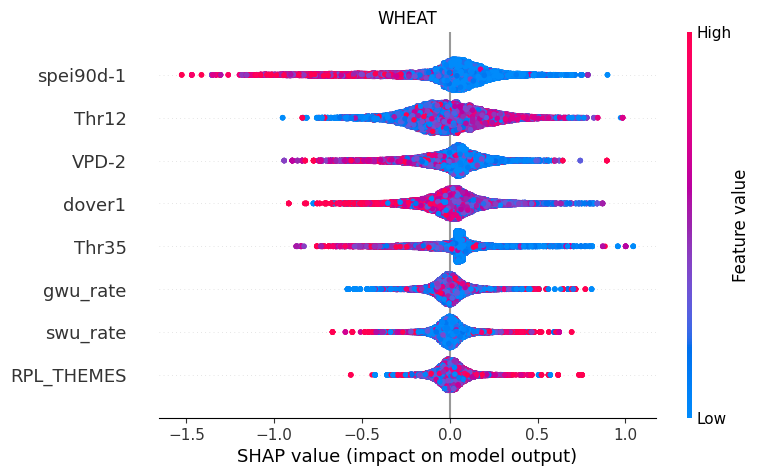

In [ ]:
import shap
import matplotlib.pyplot as plt
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X, y)
# shap.plots.beeswarm(shap_values, show=False)
shap.summary_plot(shap_values, X,show=False)
plt.title(selected_crop)
out_path = '<DATA_ROOT>/Final_Exports_2024_08/Shap_Values_All_Causes_V6/'
plt.gcf().savefig(out_path + selected_crop + ".png")
# plt.close()

In [ ]:
'VPD-Mean', 'VPD-1', 'Thr28', 'Thr30', 'Thr31', 'Thr33',
'Thr6', 'Thr10', 'Thr12', 'spei90d-1','dover1',

In [ ]:
df_merge_yield.columns

Index(['FIPS', 'Crop', 'Irrigation Practice', 'year', 'd_yield_standard',
       'Cause_of_Loss_Desc', 'RPL_THEMES', 'gwu_rate', 'swu_rate', 'Thr6',
       'Thr10', 'Thr12', 'Thr16', 'spei90d-1', 'spei30d-2', 'dover1', 'dover5',
       'VPD-Mean', 'VPD-1', 'VPD-2', 'Thr28', 'Thr30', 'Thr31', 'Thr33',
       'Thr35'],
      dtype='object')

In [ ]:
shap_values_df = pd.DataFrame(shap_values.values, columns=X.columns)
mean_abs_shap_values = np.abs(shap_values_df).mean()

most_important_factors = list(mean_abs_shap_values.nlargest(8).keys())
if 'gwu_rate' not in most_important_factors:
  most_important_factors.append('gwu_rate')
if 'swu_rate' not in most_important_factors:
  most_important_factors.append('swu_rate')

for factor in most_important_factors:
  percentiles = np.percentile(df_merge_yield[cond_crop][factor], [10, 90])
  default_size = plt.rcParams['lines.markersize'] ** 2
  half_size = default_size / 2
  plt.scatter(df_merge_yield[cond_crop].RPL_THEMES, shap_values[:,factor].values,
                                                    #shap_values[:,factor].values
              c=df_merge_yield[cond_crop][factor], s=half_size, cmap='autumn_r',
              vmin=percentiles[0], vmax=percentiles[1])
  plt.colorbar(label=f'{factor} feature value')
  plt.xlabel('RPL_THEMES feature value')
  plt.ylabel(f'{factor} shap value')
  plt.title(f'Scatter Plot of {factor}')
  plt.gcf().savefig(out_path + selected_crop + '_' + factor + ".png") # out_path
  plt.close()

# Yield Analysis Regression - old

In [ ]:
cond_irig = df_yield['prodn_practice_desc'] == 'ALL PRODUCTION PRACTICES'
df_yield = df_yield[cond_irig]
df_yield['prodn_practice_desc'] = 'ALL'
df_yield = df_yield.rename(columns={'commodity_desc':'Crop','prodn_practice_desc':'Irrigation Practice'})
df_yield['FIPS'] = df_yield['FIPS'].astype(int)

In [285]:
# df_merge_yield_ins = pd.merge(df_yield,df_insure,on=['FIPS', 'Crop', 'year'],how='outer',validate='m:m')
df_merge_yield_ins = df_yield
df_merge_yield_ins_svi = pd.merge(df_merge_yield_ins,df_svi,on=['FIPS', 'Crop', 'year'],how='outer',validate='m:1')
df_merge_yield_ins_svi_gwu = pd.merge(df_merge_yield_ins_svi,dfw,on=['FIPS', 'year'],how='outer',validate='m:1')
# df_merge_crop_ins_svi_gwu

df_merge_yield_ins_svi_gwu = df_merge_yield_ins_svi_gwu.dropna(subset='d_yield_standard')
condy = df_merge_yield_ins_svi_gwu.year < 2023
df_merge_yield_ins_svi_gwu = df_merge_yield_ins_svi_gwu[condy]

df_merge_clim = pd.merge(df_cold,df_drought,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_prcp,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_vpd,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_warm,on=['FIPS', 'year'])
# df_merge_clim

df_merge = pd.merge(df_merge_yield_ins_svi_gwu,df_merge_clim,on=['FIPS', 'year'],validate='m:1')
df_merge = df_merge.dropna()


In [ ]:
df_merge

In [ ]:
Cause_of_Loss = [
    'Insects',	'Plant Disease',	'Frost',	'Hot Wind',
    'Wildlife',	'Freeze',	'Cold Winter',	'Wind/Excess Wind',
    'Flood',	'Hail',	'Heat',	'Cold Wet Weather',	'Drought',
    'Decline in Price',	'Excess Moisture/Precipitation/Rain'
]

df_merge = df_merge[df_merge['Cause_of_Loss_Desc'].isin(Cause_of_Loss)]

In [ ]:
df_merge.iloc[0:3]

In [27]:
print(Cause_of_Loss[-1],Cause_of_Loss[-3],Cause_of_Loss[-5])

Excess Moisture/Precipitation/Rain Drought Heat


In [ ]:
cond_loss = df_merge['Cause_of_Loss_Desc'] == Cause_of_Loss[-1]

cond_ir = df_merge['Irrigation Practice'] == 'ALL'
df_merge_yield = df_merge[cond_ir & cond_loss]

In [286]:
cond_ir = df_merge['Irrigation Practice'] == 'ALL'
df_merge_yield = df_merge[cond_ir]

In [ ]:
df_merge_yield['abs_y'] = df_merge_yield['d_yield_standard'].abs()
quantiles = df_merge_yield.groupby('Crop').agg(quantile_30=('abs_y', lambda x: x.quantile(0.5)))
crops = ['BARLEY','CORN','COTTON','HAY','OATS','SORGHUM','SOYBEANS','WHEAT']
selected_crop = 'SOYBEANS' # 'WHEAT' , 'CORN' , 'SOYBEANS'
# list_df = []
# for crop in crops:
cond_crop = df_merge_yield.Crop == selected_crop
cond_quant = df_merge_yield.abs_y > quantiles.loc[selected_crop,'quantile_30']
df_merge_yield = df_merge_yield[cond_crop & cond_quant].drop(columns=['abs_y'])
# list_df.append(df_filtered)

df_merge_yield

In [288]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# selected_crop = 'HAY' # 'WHEAT' , 'CORN' , 'SOYBEANS'
cond_crop = df_merge_yield.Crop == selected_crop
df = df_merge_yield[cond_crop].drop(columns=['FIPS','Crop','Irrigation Practice','year',
                                            #  'Cause_of_Loss_Desc',
                                             ])
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
# df_scaled

In [37]:
df_merge_yield.columns

Index(['FIPS', 'Crop', 'Irrigation Practice', 'year', 'd_yield_standard',
       'Cause_of_Loss_Desc', 'RPL_THEMES', 'gwu_rate', 'swu_rate', 'Thr6',
       'Thr10', 'Thr12', 'Thr16', 'spei90d-1', 'spei30d-2', 'dover1', 'dover5',
       'VPD-Mean', 'VPD-1', 'VPD-2', 'Thr28', 'Thr30', 'Thr31', 'Thr33',
       'Thr35'],
      dtype='object')

In [297]:
import numpy as np
import random
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df_scaled.drop(columns=['d_yield_standard'])
y = df_scaled['d_yield_standard']

r2_test = 0
r2_train = 0
rst = 0
for rsi in range(1,300):
  rs = 894
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=rs) #

  params = {'max_depth': 9,
            'learning_rate': 0.04 + rsi/10000,#0.0436,
            'subsample': 0.7,
            'colsample_bytree':0.7,
            'n_estimators': 100,
            'min_child_weight':25,
            # 'gamma':1,#0.92
            # 'scale_pos_weight':1,
            # 'seed':58,
            'nthread':4,
            'n_jobs':4,
            # 'random_state':rsi
              }

  xgb_model = xgb.XGBRegressor(**params)
  xgb_model.fit(X_train, y_train)
  y_pred = xgb_model.predict(X_test)
  y_pred2 = xgb_model.predict(X_train)
  r2_ts = r2_score(y_test, y_pred)
  r2_tr = r2_score(y_train, y_pred2)

  if r2_ts > r2_test:
    rst = rs
    r2_test = r2_ts
    r2_train = r2_tr
    print(rsi)
    print("R-squared_test:", r2_ts)
    print("R-squared_train:", r2_tr)

1
R-squared_test: 0.5436009850534448
R-squared_train: 0.6458961045480978
3
R-squared_test: 0.5436018283297793
R-squared_train: 0.6524334138061669
4
R-squared_test: 0.5443036199513162
R-squared_train: 0.6494262722950248
6
R-squared_test: 0.545304493409627
R-squared_train: 0.6528220269628678
9
R-squared_test: 0.5456570496475086
R-squared_train: 0.6529868046175237
11
R-squared_test: 0.5460707045423778
R-squared_train: 0.6538056163693472
14
R-squared_test: 0.5487182486891773
R-squared_train: 0.6533391976494496
28
R-squared_test: 0.5500244625358364
R-squared_train: 0.6626980534208411
51
R-squared_test: 0.5506629431541639
R-squared_train: 0.6643541894988771
54
R-squared_test: 0.5528153111161807
R-squared_train: 0.6676406537331312
79
R-squared_test: 0.5538092678046168
R-squared_train: 0.6730352336140069
104
R-squared_test: 0.554297950154301
R-squared_train: 0.6784875856684265
109
R-squared_test: 0.5545174660593721
R-squared_train: 0.679200103093233
153
R-squared_test: 0.55455832849527
R-squar

In [269]:
rs  , r2_ts , r2_tr

(34, 0.10070945291828148, 0.08790134684360273)

In [ ]:
# CORN & Drought
# params = {'max_depth': 8,
#           'learning_rate': 0.05,
#           'subsample': 0.7,
#           'n_estimators': 80,
#           }
# 844
# R-squared_test: 0.46155330105706616
# R-squared_train: 0.6746792782195327

# SOYBEANS & Drought
# params = {'max_depth': 8,
#           'learning_rate': 0.05,
#           'subsample': 0.7,
#           'n_estimators': 80,
#           }
# 684
# R-squared_test: 0.49923572796902016
# R-squared_train: 0.689392215053871

# WHEAT & Drought
# params = {'max_depth': 8,
#           'learning_rate': 0.05,
#           'subsample': 0.7,
#           'n_estimators': 80,
#           }
# 839
# R-squared_test: 0.43937401810441945
# R-squared_train: 0.7249977328203635

# CORN & Heat
# params = {'max_depth': 7,
#           'learning_rate': 0.05,
#           'subsample': 0.7,
#           'n_estimators': 50,
#           }
# 299
# R-squared_test: 0.5111015887921304
# R-squared_train: 0.6118917592845656

# SOYBEANS & Heat
# params = {'max_depth': 7,
#           'learning_rate': 0.05,
#           'subsample': 0.65,
#           'n_estimators': 75,
#           }
# 299
# R-squared_test: 0.550182377402537
# R-squared_train: 0.7098744806377119

# WHEAT & Heat
# params = {'max_depth': 7,
#           'learning_rate': 0.05,
#           'subsample': 0.65,
#           'n_estimators': 50,
#           }
# 254
# R-squared_test: 0.4642958043890488
# R-squared_train: 0.6932902352941758

# CORN & Excess Moisture
# params = {'max_depth': 7,
#           'learning_rate': 0.05,
#           'subsample': 0.8,
#           'n_estimators': 90,
#           }
# 610
# R-squared_test: 0.3921169462619215
# R-squared_train: 0.5645916564103144

# SOYBEANS & Excess Moisture
# params = {'max_depth': 8,
#           'learning_rate': 0.05,
#           'subsample': 0.7,
#           'n_estimators': 80,
#           }
# 620
# R-squared_test: 0.477513347659252
# R-squared_train: 0.6404312417582452

# WHEAT & Excess Moisture
# params = {'max_depth': 8,
#             'learning_rate': 0.05,
#             'subsample': 0.7,
#             'n_estimators': 100,
#             }
# 412
# R-squared_test: 0.3463898459978838
# R-squared_train: 0.6559706226902822


# **Yield Analysis Regression - Shap Values**

In [ ]:
!pip install shap scikit-learn pandas

In [ ]:
cond_irig = df_yield['prodn_practice_desc'] == 'ALL PRODUCTION PRACTICES'
df_yield = df_yield[cond_irig]
df_yield['prodn_practice_desc'] = 'ALL'
df_yield = df_yield.rename(columns={'commodity_desc':'Crop','prodn_practice_desc':'Irrigation Practice'})
df_yield['FIPS'] = df_yield['FIPS'].astype(int)

In [23]:
df_merge_yield_ins = pd.merge(df_yield,df_insure,on=['FIPS', 'Crop', 'year'],how='outer',validate='m:m')
df_merge_yield_ins_svi = pd.merge(df_merge_yield_ins,df_svi,on=['FIPS', 'Crop', 'year'],how='outer',validate='m:1')
df_merge_yield_ins_svi_gwu = pd.merge(df_merge_yield_ins_svi,dfw,on=['FIPS', 'year'],how='outer',validate='m:1')
# df_merge_crop_ins_svi_gwu

df_merge_yield_ins_svi_gwu = df_merge_yield_ins_svi_gwu.dropna(subset='d_yield_standard')
condy = df_merge_yield_ins_svi_gwu.year < 2023
df_merge_yield_ins_svi_gwu = df_merge_yield_ins_svi_gwu[condy]

df_merge_clim = pd.merge(df_cold,df_drought,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_prcp,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_vpd,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_warm,on=['FIPS', 'year'])
# df_merge_clim

df_merge = pd.merge(df_merge_yield_ins_svi_gwu,df_merge_clim,on=['FIPS', 'year'],validate='m:1')
df_merge = df_merge.dropna()


In [24]:
Cause_of_Loss = [
    'Insects',	'Plant Disease',	'Frost',	'Hot Wind',
    'Wildlife',	'Freeze',	'Cold Winter',	'Wind/Excess Wind',
    'Flood',	'Hail',	'Heat',	'Cold Wet Weather',	'Drought',
    'Decline in Price',	'Excess Moisture/Precipitation/Rain'
]

df_merge = df_merge[df_merge['Cause_of_Loss_Desc'].isin(Cause_of_Loss)]

In [46]:
crops = ['CORN', 'CORN', 'CORN', 'SOYBEANS' , 'SOYBEANS' , 'SOYBEANS' , 'WHEAT' , 'WHEAT' , 'WHEAT']
cause_of_loss = ['Drought' , 'Heat' , 'Excess Moisture/Precipitation/Rain' ,
                 'Drought' , 'Heat' , 'Excess Moisture/Precipitation/Rain' ,
                 'Drought' , 'Heat' , 'Excess Moisture/Precipitation/Rain' , ]
data = {
    'Crop': [], 'Cause_of_Loss' : [] , 'random_state': [], 'max_depth': [],
    'learning_rate': [], 'subsample': [], 'n_estimators': []
}

df = pd.DataFrame(data)
df.Crop = crops
df.Cause_of_Loss = cause_of_loss
df = df.set_index(['Crop' , 	'Cause_of_Loss'])

df.loc[('CORN','Drought'),:] = {
    'random_state':844, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.7, 'n_estimators': 80}
df.loc[('CORN','Heat'),:] = {
    'random_state':299, 'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.7, 'n_estimators': 50}
df.loc[('CORN','Excess Moisture/Precipitation/Rain'),:] = {
    # 'random_state':610, 'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.8, 'n_estimators': 90
    'random_state':177, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.7, 'n_estimators': 90
    }

# R-squared_test: 0.46155330105706616         41336214701699814
# R-squared_test: 0.5111015887921304          4656980993624359
# R-squared_test: 0.3921169462619215          35129078786913126

df.loc[('SOYBEANS','Drought'),:] = {
    'random_state':684, 'max_depth': 8, 'learning_rate': 0.05,  'subsample': 0.7, 'n_estimators': 80}
df.loc[('SOYBEANS','Heat'),:] = {
    'random_state':299, 'max_depth': 7, 'learning_rate': 0.05,  'subsample': 0.65,  'n_estimators': 75}
df.loc[('SOYBEANS','Excess Moisture/Precipitation/Rain'),:] = {
    'random_state':620, 'max_depth': 8, 'learning_rate': 0.05,  'subsample': 0.7,  'n_estimators': 80}

# R-squared_test: 0.49923572796902016       44472788544155906
# R-squared_test: 0.550182377402537         5104996263232613
# R-squared_test: 0.477513347659252         41515451384038526

df.loc[('WHEAT','Drought'),:] = {
    'random_state':839, 'max_depth': 8, 'learning_rate': 0.05,  'subsample': 0.7,  'n_estimators': 80}
df.loc[('WHEAT','Heat'),:] = {
    'random_state':254, 'max_depth': 7, 'learning_rate': 0.05,  'subsample': 0.65, 'n_estimators': 50}
df.loc[('WHEAT','Excess Moisture/Precipitation/Rain'),:] = {
    'random_state':412, 'max_depth': 8, 'learning_rate': 0.05,  'subsample': 0.7, 'n_estimators': 100}

# R-squared_test: 0.43937401810441945       4028839863848983
# R-squared_test: 0.4642958043890488        42745492018625597
# R-squared_test: 0.3463898459978838        29148717025173077

df_params = df.copy()
# df


In [49]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import random
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import shap
import matplotlib.pyplot as plt

# crops = ['CORN', 'SOYBEANS' , 'WHEAT']
# causes = ['Drought' , 'Heat' , 'Excess Moisture/Precipitation/Rain']
crops = ['COTTON', ]
causes = ['Excess Moisture/Precipitation/Rain']

for selected_crop in crops:
  for selected_caus in causes:
    cond_loss = df_merge['Cause_of_Loss_Desc'] == selected_caus
    cond_ir = df_merge['Irrigation Practice'] == 'ALL'
    df_merge_yield = df_merge[cond_ir & cond_loss]

    cond_crop = df_merge_yield.Crop == selected_crop
    df = df_merge_yield[cond_crop].drop(columns=['FIPS','Crop','Irrigation Practice','year','Cause_of_Loss_Desc',])
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

    params_dict = df_params.loc[(selected_crop,selected_caus)]
    random_state = (params_dict.random_state).astype(int)
    params = {'max_depth': (params_dict.max_depth).astype(int),
              'learning_rate': params_dict.learning_rate,
              'subsample': params_dict.subsample,
              'n_estimators': (params_dict.n_estimators).astype(int),
              'random_state': (params_dict.random_state).astype(int),
              }

    X = df_scaled.drop(columns=['d_yield_standard'])
    y = df_scaled['d_yield_standard']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=random_state)

    xgb_model = xgb.XGBRegressor(**params)
    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_test)
    y_pred2 = xgb_model.predict(X_train)
    r2_ts = r2_score(y_test, y_pred)
    r2_tr = r2_score(y_train, y_pred2)

    print(selected_crop , selected_caus , ':')
    print("R-squared_test:", r2_ts , "R-squared_train:", r2_tr)

    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer(X, y)
    # shap.plots.beeswarm(shap_values, show=False)
    shap.summary_plot(shap_values, X,show=False)

    plt.title(selected_crop + ' ' +  selected_caus)
    # out_path = '<DATA_ROOT>/Final_Exports_2024_08/Shap_Values_Plots_V2/'
    out_path = '/content/'
    if   selected_caus == 'Excess Moisture/Precipitation/Rain':
      selected_caus = 'Excess_Moisture'
    plt.gcf().savefig(out_path + selected_crop + '_' +  selected_caus + ".png")
    plt.close()

    shap_values_df = pd.DataFrame(shap_values.values, columns=X.columns)
    mean_abs_shap_values = np.abs(shap_values_df).mean()

    most_important_factors = list(mean_abs_shap_values.nlargest(6).keys())
    if 'gwu_rate' not in most_important_factors:
      most_important_factors.append('gwu_rate')
    if 'swu_rate' not in most_important_factors:
      most_important_factors.append('swu_rate')

    for factor in most_important_factors:
      percentiles = np.percentile(df_merge_yield[cond_crop][factor], [10, 90])
      default_size = plt.rcParams['lines.markersize'] ** 2
      half_size = default_size / 2
      plt.scatter(df_merge_yield[cond_crop].RPL_THEMES, shap_values[:,factor].values,
                  c=df_merge_yield[cond_crop][factor], s=half_size, cmap='autumn_r',
                  vmin=percentiles[0], vmax=percentiles[1])
      plt.colorbar(label=f'{factor} feature value')
      plt.xlabel('RPL_THEMES feature value')
      plt.ylabel(f'{factor} shap value')
      plt.title(f'Scatter Plot of {factor}')
      plt.gcf().savefig( out_path + selected_crop + '_' +  selected_caus + '_' + factor + ".png") # out_path
      plt.close()

CORN Excess Moisture/Precipitation/Rain :
R-squared_test: 0.22441044268918564 R-squared_train: 0.2746694794064096


In [81]:
df_merge_yield.columns
['Thr6', 'Thr10', 'Thr12','spei90d-1', 'dover1',
 'VPD-Mean', 'VPD-2', 'Thr28', 'Thr30', 'Thr31', 'Thr35']

Index(['FIPS', 'Crop', 'Irrigation Practice', 'year', 'd_yield_standard',
       'RPL_THEMES', 'gwu_rate', 'swu_rate', 'Thr6', 'Thr10', 'Thr12', 'Thr16',
       'spei90d-1', 'spei30d-2', 'dover1', 'dover5', 'VPD-Mean', 'VPD-1',
       'VPD-2', 'Thr28', 'Thr30', 'Thr31', 'Thr33', 'Thr35'],
      dtype='object')

In [284]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import random
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import shap
import matplotlib.pyplot as plt

# cond_ir = df_merge['Irrigation Practice'] == 'ALL'
# df_merge_yield = df_merge[cond_ir]

# crops = ['CORN', 'SOYBEANS' , 'WHEAT']
selected_crop = 'HAY'
cond_crop = df_merge_yield.Crop == selected_crop
df = df_merge_yield[cond_crop].drop(columns=['FIPS','Crop','Irrigation Practice','year'])
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

random_state = 34
params = {'max_depth': 9,
          'learning_rate': 0.05,#0.0436,
          'subsample': 0.82,
          'colsample_bytree':0.7,
          'n_estimators': 118,
          'min_child_weight':17,
          'gamma':1,#0.92
          'scale_pos_weight':1,
          'seed':58,
          'nthread':4,
          'n_jobs':4,
          # 'random_state':rsi
            }

X = df_scaled.drop(columns=['d_yield_standard'])
y = df_scaled['d_yield_standard']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=random_state)

xgb_model = xgb.XGBRegressor(**params)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
y_pred2 = xgb_model.predict(X_train)
r2_ts = r2_score(y_test, y_pred)
r2_tr = r2_score(y_train, y_pred2)

print(selected_crop , selected_caus , ':')
print("R-squared_test:", r2_ts , "R-squared_train:", r2_tr)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X, y)
# shap.plots.beeswarm(shap_values, show=False)
shap.summary_plot(shap_values, X,show=False)

plt.title(selected_crop)
# out_path = '<DATA_ROOT>/Final_Exports_2024_08/Shap_Values_Plots_V2/'
out_path = '/content/'

plt.gcf().savefig(out_path + selected_crop + ".png")
plt.close()

shap_values_df = pd.DataFrame(shap_values.values, columns=X.columns)
mean_abs_shap_values = np.abs(shap_values_df).mean()

most_important_factors = list(mean_abs_shap_values.nlargest(19).keys())
if 'gwu_rate' not in most_important_factors:
  most_important_factors.append('gwu_rate')
if 'swu_rate' not in most_important_factors:
  most_important_factors.append('swu_rate')

for factor in most_important_factors:
  percentiles = np.percentile(df_merge_yield[cond_crop][factor], [10, 90])
  default_size = plt.rcParams['lines.markersize'] ** 2
  half_size = default_size / 2
  plt.scatter(df_merge_yield[cond_crop].RPL_THEMES, shap_values[:,factor].values,
              c=df_merge_yield[cond_crop][factor], s=half_size, cmap='autumn_r',
              vmin=percentiles[0], vmax=percentiles[1])
  plt.colorbar(label=f'{factor} feature value')
  plt.xlabel('RPL_THEMES feature value')
  plt.ylabel(f'{factor} shap value')
  plt.title(f'Scatter Plot of {factor}')
  plt.gcf().savefig( out_path + selected_crop + '_' + factor + ".png") # out_path
  plt.close()

HAY Excess_Moisture :
R-squared_test: 0.2527918173654944 R-squared_train: 0.6486205229961067


# **shap values plot - old**

In [ ]:
df_merge.columns

Index(['FIPS', 'Crop', 'Irrigation Practice', 'year', 'd_yield_standard',
       'Cause_of_Loss_Desc', 'RPL_THEMES', 'gwu_rate', 'swu_rate', 'Thr0',
       'spei90d-1', 'spei30d-2', 'dover1', 'dover5', 'VPD-Mean', 'VPD-1',
       'VPD-2', 'Thr28', 'Thr30', 'Thr31', 'Thr33', 'Thr35'],
      dtype='object')

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

crops = ['CORN', 'SOYBEANS' , 'WHEAT']
causes = ['Drought' , 'Heat' , 'Excess Moisture/Precipitation/Rain']
selected_crop = crops[1]
selected_caus = causes[2]

cond_loss = df_merge['Cause_of_Loss_Desc'] == selected_caus
cond_ir = df_merge['Irrigation Practice'] == 'ALL'
df_merge_yield = df_merge[cond_ir & cond_loss]

cond_crop = df_merge_yield.Crop == selected_crop
df = df_merge_yield[cond_crop].drop(columns=['FIPS','Crop','Irrigation Practice','year','Cause_of_Loss_Desc',
                                             'RPL_THEMES','Thr0', 'VPD-Mean', 'VPD-1',
                                             'Thr28', 'Thr31', 'Thr33', 'Thr35'])
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

params_dict = df_params.loc[(selected_crop,selected_caus)]
random_state = (params_dict.random_state).astype(int)
params = {'max_depth': (params_dict.max_depth).astype(int),
          'learning_rate': params_dict.learning_rate,
          'subsample': params_dict.subsample,
          'n_estimators': (params_dict.n_estimators).astype(int),
          }

In [ ]:
df_scaled.columns

Index(['d_yield_standard', 'gwu_rate', 'swu_rate', 'Thr-2', 'pdsi-2', 'dpi1',
       'VPD-Mean', 'VPD-1', 'VPD-2', 'Thr28', 'Thr31', 'Thr33', 'Thr35'],
      dtype='object')

In [ ]:
import numpy as np
import random
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df_scaled.drop(columns=['d_yield_standard'])
y = df_scaled['d_yield_standard']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=random_state)

xgb_model = xgb.XGBRegressor(**params)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
y_pred2 = xgb_model.predict(X_train)
r2_ts = r2_score(y_test, y_pred)
r2_tr = r2_score(y_train, y_pred2)

print("R-squared_test:", r2_ts)
print("R-squared_train:", r2_tr)


R-squared_test: 0.375394554322967
R-squared_train: 0.5603667448123083


In [ ]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X, y)
shap.plots.beeswarm(shap_values)



In [ ]:
# shap.plots.scatter(shap_values[:,"VPD-1"],color=shap_values[:,"RPL_THEMES"])
plt.scatter(df_merge_yield[cond_crop].RPL_THEMES,shap_values[:,"VPD-2"].values,
            c=df_scaled["VPD-2"], cmap='RdBu_r')
plt.colorbar(label='VPD-2 feature value')
plt.xlabel('RPL_THEMES feature value')
plt.ylabel('VPD-2 shap value')
plt.title('Scatter Plot VPD-2')


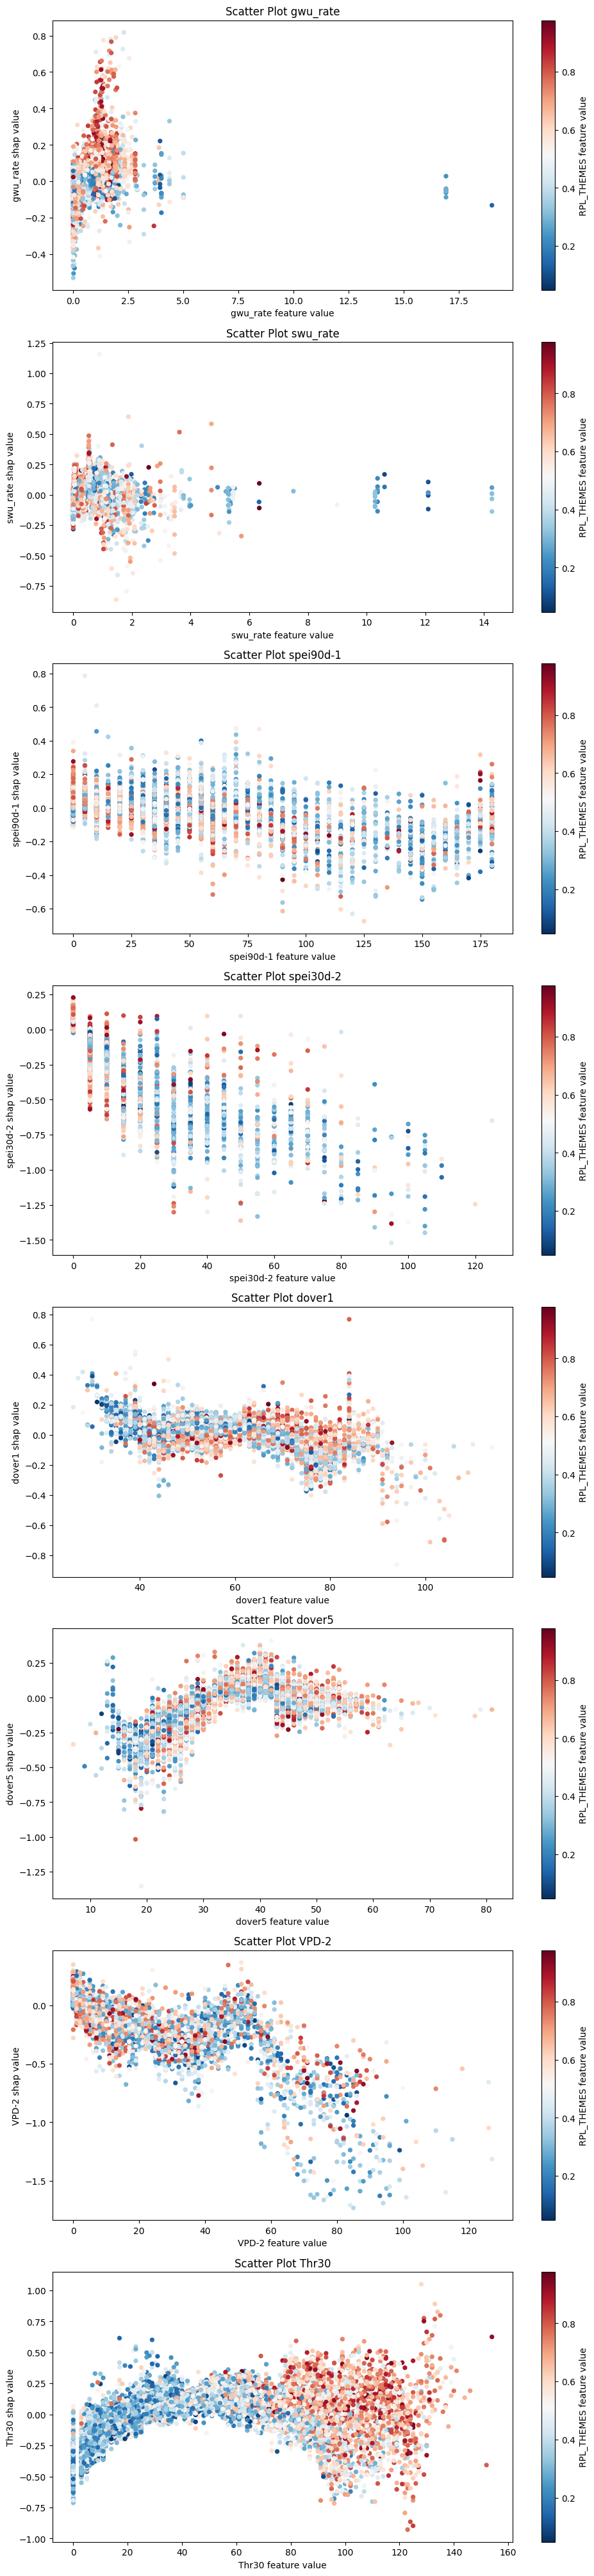

In [ ]:
cols = list(X.columns)
i = 1
plt.figure(figsize=(10, 60))

for col in cols:
  default_size = plt.rcParams['lines.markersize'] ** 2
  half_size = default_size / 2
  percentiles = np.percentile(df_scaled[col], [10, 90])
  plt.subplot(12, 1, i)
  plt.scatter(df_merge_yield[cond_crop][col],shap_values[:,col].values,
              c=df_merge_yield[cond_crop].RPL_THEMES, cmap='RdBu_r', s=half_size, )
              # vmin=percentiles[0], vmax=percentiles[1])
  plt.colorbar(label='RPL_THEMES feature value')
  plt.xlabel(f'{col} feature value')
  plt.ylabel(f'{col} shap value')
  plt.title(f'Scatter Plot {col}')
  i = i + 1
  # if col == 'gwu_rate':
  #   plt.xlim(xmax=4)
  # if col == 'swu_rate':
  #   plt.xlim(xmax=5)
  # if col == 'dover1':
  #   plt.ylim(ymax=1)
  # if col == 'dover5':
  #   plt.ylim(ymax=1)
plt.tight_layout()
plt.show()


In [ ]:
shap_values

In [ ]:
X.columns

Index(['gwu_rate', 'swu_rate', 'Thr-2', 'pdsi-2', 'dpi1', 'VPD-Mean', 'VPD-1',
       'VPD-2', 'Thr28', 'Thr31', 'Thr33', 'Thr35'],
      dtype='object')

<Axes: xlabel='RPL_THEMES'>

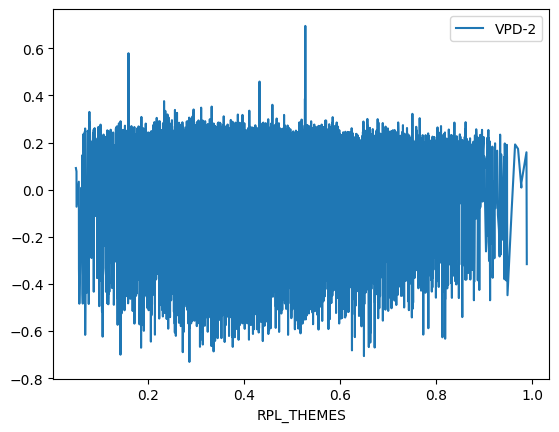

In [ ]:
df = df_merge_yield[cond_crop].RPL_THEMES.to_frame()
# df['VPD-Mean'] = np.array(X['VPD-Mean'])
df['VPD-2'] = shap_values[:,"VPD-2"].values
# shap_values.values[:,7]
df = df.sort_values(by=['RPL_THEMES'])
df.plot(x='RPL_THEMES', y='VPD-2', kind='line')

In [ ]:
df

,RPL_THEMES,VPD-Mean
200881,0.050679,0.092091
200856,0.051161,-0.287908
61537,0.062582,0.393759
72392,0.064079,0.253234
137986,0.064184,0.092091
...,...,...
271980,0.946123,-1.749928
271994,0.946297,0.393759
271962,0.946656,0.175725
273893,0.948112,-0.432011


from matplotlib import pyplot as plt
df['RPL_THEMES'].plot(kind='hist', bins=20, title='RPL_THEMES')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['VPD-Mean'].plot(kind='hist', bins=20, title='VPD-Mean')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='RPL_THEMES', y='VPD-Mean', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['RPL_THEMES']
  ys = series['VPD-Mean']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('RPL_THEMES', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('RPL_THEMES')
_ = plt.ylabel('VPD-Mean')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['RPL_THEMES']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'RPL_THEMES'}, axis=1)
              .sort_values('RPL_THEMES', ascending=True))
  xs = counted['RPL_THEMES']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('RPL_THEMES', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('RPL_THEMES')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
df['RPL_THEMES'].plot(kind='line', figsize=(8, 4), title='RPL_THEMES')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['VPD-Mean'].plot(kind='line', figsize=(8, 4), title='VPD-Mean')
plt.gca().spines[['top', 'right']].set_visible(False)

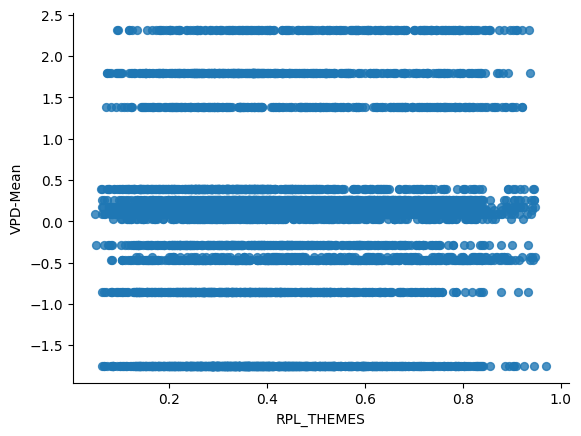

In [ ]:
from matplotlib import pyplot as plt
df.plot(kind='scatter', x='RPL_THEMES', y='VPD-Mean', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

# **Yield Analysis Classification**

In [ ]:
Cause_of_Loss = [
    'Insects',	'Plant Disease',	'Frost',	'Hot Wind',
    'Wildlife',	'Freeze',	'Cold Winter',	'Wind/Excess Wind',
    'Flood',	'Hail',	'Heat',	'Cold Wet Weather',	'Drought',
    'Decline in Price',	'Excess Moisture/Precipitation/Rain'
]

df_merge = df_merge[df_merge['Cause_of_Loss_Desc'].isin(Cause_of_Loss)]

In [ ]:
Cause_of_Loss[-3]

'Drought'

In [ ]:
cond_loss = df_merge['Cause_of_Loss_Desc'] == Cause_of_Loss[-3]

cond_ir = df_merge['Irrigation Practice'] == 'ALL'
df_merge_yield = df_merge[cond_ir & cond_loss]

In [ ]:
df_merge_yield.iloc[0:3]

,FIPS,Crop,Irrigation Practice,year,d_yield_standard,Cause_of_Loss_Desc,RPL_THEMES,gwu_rate,swu_rate,Thr-2,pdsi-2,dpi1,VPD-Mean,Thr31
261,4021,COTTON,ALL,2009,0.125043,Drought,0.815113,2.938925,2.639387,0.0,0.0,3.134537,1.403033,155.0
484,5017,SOYBEANS,ALL,2009,-0.116996,Drought,0.738447,1.102376,0.401353,0.0,0.0,13.794796,1.403033,55.0
490,5017,WHEAT,ALL,2009,-0.193425,Drought,0.720313,1.102376,0.401353,0.0,0.0,13.794796,1.403033,55.0


In [ ]:
df_merge_yield.groupby('Crop').count().FIPS

Crop
BARLEY        654
CORN        13056
COTTON       2685
OATS          997
SORGHUM      1960
SOYBEANS    13144
WHEAT        7137
Name: FIPS, dtype: int64

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

selected_crop = 'SOYBEANS' # 'WHEAT' , 'CORN' , 'SOYBEANS'
cond_crop = df_merge_yield.Crop == selected_crop
df = df_merge_yield[cond_crop].drop(columns=['FIPS','Crop','Irrigation Practice','year','Cause_of_Loss_Desc'])
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
# df_scaled

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df_scaled.drop(columns=['d_yield_standard'])
y = df_scaled['d_yield_standard']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=49) #

params = {'max_depth': 10,
          'learning_rate': 0.01,
          'subsample': 0.6,
          'n_estimators': 750,
          }

xgb_model = xgb.XGBRegressor(**params)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_pred2 = xgb_model.predict(X_train)

r2 = r2_score(y_test, y_pred)
print("R-squared_test:", r2)

r2 = r2_score(y_train, y_pred2)
print("R-squared_train:", r2)


R-squared_test: 0.4502600637230836
R-squared_train: 0.8869461958822178


In [ ]:
# params = {'max_depth': 7,
#           'learning_rate': 0.001,
#           'subsample': 0.8,
#           'colsample_bytree': 0.75,
#           'colsample_bylevel': 0.75,
#           'n_estimators': 100,
#           'max_leaves':100
#             }

# **Failure Analysis Regression**

In [ ]:
cond_irig = df_fail['Irrigation Practice'] == 'ALL'
df_fail = df_fail[cond_irig]
df_fail['FIPS'] = df_fail['FIPS'].astype(int)

In [ ]:
df_merge_fail_ins = pd.merge(df_fail,df_insure,on=['FIPS', 'Crop', 'year'],how='outer',validate='m:m')
df_merge_fail_ins_svi = pd.merge(df_merge_fail_ins,df_svi,on=['FIPS', 'Crop', 'year'],how='outer',validate='m:1')
df_merge_fail_ins_svi_gwu = pd.merge(df_merge_fail_ins_svi,dfw,on=['FIPS', 'year'],how='outer',validate='m:1')
# df_merge_crop_ins_svi_gwu

df_merge_fail_ins_svi_gwu = df_merge_fail_ins_svi_gwu.dropna(subset='fail_share')
condy = df_merge_fail_ins_svi_gwu.year < 2023
df_merge_fail_ins_svi_gwu = df_merge_fail_ins_svi_gwu[condy]

df_merge_clim = pd.merge(df_cold,df_drought,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_prcp,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_vpd,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_warm,on=['FIPS', 'year'])
# df_merge_clim

df_merge = pd.merge(df_merge_fail_ins_svi_gwu,df_merge_clim,on=['FIPS', 'year'],validate='m:1')
df_merge = df_merge.dropna()
df_merge.iloc[0:3]

,FIPS,Crop,Irrigation Practice,year,fail_share,Cause_of_Loss_Desc,RPL_THEMES,gwu_rate,swu_rate,Thr-2,pdsi-2,dpi1,VPD-Mean,Thr31
0,1001,SOYBEANS,ALL,2009,0.0,Drought,0.701829,1.610738,0.255034,0.0,0.0,10.568762,1.403033,60.0
1,1001,SOYBEANS,ALL,2009,0.0,Excess Moisture/Precipitation/Rain,0.701829,1.610738,0.255034,0.0,0.0,10.568762,1.403033,60.0
3,1001,WHEAT,ALL,2009,0.0,Excess Moisture/Precipitation/Rain,0.676241,1.610738,0.255034,0.0,0.0,10.568762,1.403033,60.0


In [ ]:
cond_fail0 = df_merge.fail_share > 0
df_merge = df_merge[cond_fail0]
df_merge.iloc[0:3]

,FIPS,Crop,Irrigation Practice,year,fail_share,Cause_of_Loss_Desc,RPL_THEMES,gwu_rate,swu_rate,Thr-2,pdsi-2,dpi1,VPD-Mean,Thr31
89,1019,SOYBEANS,ALL,2009,0.000384,Drought,0.501997,0.0,1.18018,0.0,45.0,10.488087,1.403033,35.0
90,1019,SOYBEANS,ALL,2009,0.000384,Excess Moisture/Precipitation/Rain,0.501997,0.0,1.18018,0.0,45.0,10.488087,1.403033,35.0
91,1019,SOYBEANS,ALL,2009,0.000384,Cold Wet Weather,0.501997,0.0,1.18018,0.0,45.0,10.488087,1.403033,35.0


In [ ]:
Cause_of_Loss = [
    'Insects',	'Plant Disease',	'Frost',	'Hot Wind',
    'Wildlife',	'Freeze',	'Cold Winter',	'Wind/Excess Wind',
    'Flood',	'Hail',	'Heat',	'Cold Wet Weather',	'Drought',
    'Decline in Price',	'Excess Moisture/Precipitation/Rain'
]

df_merge = df_merge[df_merge['Cause_of_Loss_Desc'].isin(Cause_of_Loss)]

In [ ]:
Cause_of_Loss[-3]

'Drought'

In [ ]:
cond_loss = df_merge['Cause_of_Loss_Desc'] == Cause_of_Loss[-3]

cond_ir = df_merge['Irrigation Practice'] == 'ALL'
df_merge_fail = df_merge[cond_ir & cond_loss]

In [ ]:
df_merge_fail.groupby('Crop').count().FIPS

Crop
BARLEY        79
CORN        3360
COTTON      1035
OATS         121
SORGHUM      415
SOYBEANS    2152
WHEAT       3672
Name: FIPS, dtype: int64

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

selected_crop = 'CORN' # 'WHEAT' , 'CORN' , 'SOYBEANS'
cond_crop = df_merge_fail.Crop == selected_crop
df = df_merge_fail[cond_crop].drop(columns=['FIPS','Crop','Irrigation Practice','year','Cause_of_Loss_Desc'])
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
# df_scaled

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df_scaled.drop(columns=['fail_share'])
y = df_scaled['fail_share']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=85) #

params = {'max_depth': 10,
          'learning_rate': 0.01,
          'subsample': 0.6,
          'n_estimators': 750,
          }

xgb_model = xgb.XGBRegressor(**params)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_pred2 = xgb_model.predict(X_train)

r2 = r2_score(y_test, y_pred)
print("R-squared_test:", r2)

r2 = r2_score(y_train, y_pred2)
print("R-squared_train:", r2)


R-squared_test: 0.07235949343805248
R-squared_train: 0.9288371903207658


# **Failure Analysis Classification**

In [ ]:
Cause_of_Loss = [
    'Insects',	'Plant Disease',	'Frost',	'Hot Wind',
    'Wildlife',	'Freeze',	'Cold Winter',	'Wind/Excess Wind',
    'Flood',	'Hail',	'Heat',	'Cold Wet Weather',	'Drought',
    'Decline in Price',	'Excess Moisture/Precipitation/Rain'
]

df_merge = df_merge[df_merge['Cause_of_Loss_Desc'].isin(Cause_of_Loss)]

In [ ]:
Cause_of_Loss[-3]

'Drought'

In [ ]:
cond_loss = df_merge['Cause_of_Loss_Desc'] == Cause_of_Loss[-3]

cond_ir = df_merge['Irrigation Practice'] == 'ALL'
df_merge_fail = df_merge[cond_ir & cond_loss]

selected_crop = 'WHEAT' # 'WHEAT' , 'CORN' , 'SOYBEANS'
cond_crop = df_merge_fail.Crop == selected_crop
df_merge_fail = df_merge_fail[cond_crop].drop(
    columns=['FIPS','Crop','Irrigation Practice','year','Cause_of_Loss_Desc'])

df_merge_fail.iloc[0:3]

,fail_share,RPL_THEMES,gwu_rate,swu_rate,Thr-2,pdsi-2,dpi1,VPD-Mean,Thr31
548,0.005521,0.293477,0.637931,0.370690,0.0,110.0,12.182564,1.403033,41.0
592,0.001429,0.502361,0.240275,0.704805,0.0,120.0,13.140871,1.403033,29.0
1026,0.017364,0.720313,1.102376,0.401353,0.0,0.0,13.794796,1.403033,55.0


In [ ]:
import numpy as np
bins = list(df_merge_fail.fail_share.quantile(np.arange(0,0.98,0.3333)))
# bins = list(dff[dff.fail_share>0].fail_share.quantile(np.arange(0,1,0.25)))
# bins = list(dff[dff.fail_share>0].fail_share.quantile([0, 0.3333, 0.5, 0.6666]))
bins = bins + [1]
labels = list(np.arange(0,3))
df_merge_fail['fail_cls'] = df_merge_fail.fail_share.to_frame().apply(lambda x: pd.cut(x, bins=bins, labels=labels), axis=0)
df_merge_fail['fail_cls'] = df_merge_fail['fail_cls'].fillna(0)

df_merge_fail = df_merge_fail.drop(columns=['fail_share'])


In [ ]:
df_merge_fail.iloc[0:3]

,RPL_THEMES,gwu_rate,swu_rate,Thr-2,pdsi-2,dpi1,VPD-Mean,Thr31,fail_cls
548,0.293477,0.637931,0.370690,0.0,110.0,12.182564,1.403033,41.0,0
592,0.502361,0.240275,0.704805,0.0,120.0,13.140871,1.403033,29.0,0
1026,0.720313,1.102376,0.401353,0.0,0.0,13.794796,1.403033,55.0,1


In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

y = df_merge_fail['fail_cls']
X = df_merge_fail.drop(columns=['fail_cls'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=85)

params = {'max_depth': 7,
          'learning_rate': 0.055,
          'subsample': 0.65,
          'colsample_bytree': 0.8,
          'colsample_bylevel': 0.75,
          'n_estimators': 650,
          'booster': 'gbtree',
          'max_leaves':100,
          }

xgb_model = xgb.XGBClassifier(**params)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_pred2 = xgb_model.predict(X_train)

accuracy_test = accuracy_score(y_test, y_pred)
print("Accuracy_test: %.2f%%" % (accuracy_test * 100.0))
accuracy_train = accuracy_score(y_train, y_pred2)
print("Accuracy_train: %.2f%%" % (accuracy_train * 100.0))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(np.array([cm[0,0],cm[1,1],cm[2,2]])/np.sum(cm,axis=1))

Accuracy_test: 45.65%
Accuracy_train: 98.46%
[0.47169811 0.34146341 0.54676259]


[0.47169811 0.34146341 0.54676259]


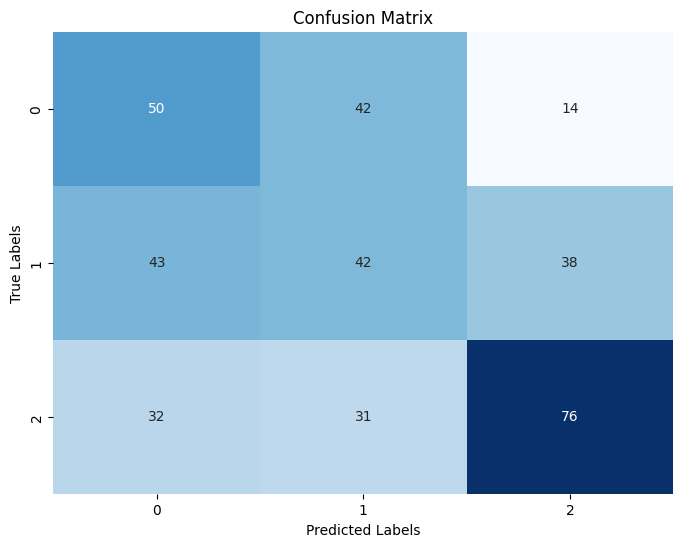

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming y_true are the true labels and y_pred are the predicted labels
# Replace y_true and y_pred with your actual true and predicted labels

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)
# cm = confusion_matrix(y_train, y_pred2)
print(np.array([cm[0,0],cm[1,1],cm[2,2]])/np.sum(cm,axis=1))
# Display confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
